# 1. Libraries

In [1]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch
from torch import nn
from torch import optim
from torch.optim import lr_scheduler
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset
import torch.nn.functional as F
from torch.nn.utils import weight_norm

In [2]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
if torch.cuda.is_available():
 Device = 'cuda'
elif torch.backends.mps.is_available():
 Device = 'mps'
else:
 Device = 'cpu'
print(f'Device is {Device}')


Device is cuda


# 2. Data loading

In [4]:
# We define column names before importing the data:

columns = ['unit', 'time', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1,22)]

In [5]:
train_data = pd.read_csv('CMAPSSData/train_FD001.txt', sep=r'\s+', header = None, names =columns)
test_data = pd.read_csv('CMAPSSData/test_FD001.txt', sep=r'\s+', header = None, names =columns)
rul_test = pd.read_csv('CMAPSSData/RUL_FD001.txt', sep=r'\s+', header = None, names =['RUL'])

In [6]:
train_data.head()

,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
train_data.shape

(20631, 26)

# 3. Data preprocessing

We will review how many units we have

In [8]:
train_data['unit'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100], dtype=int64)

## 3.1 Creation of RUL (Target column)

Now, we will create the RUL column

In [9]:
train_data['RUL']= train_data.groupby('unit')['time'].transform('max') - train_data['time']
train_data.head(3)

,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189


Let's review that the RUL column was created correctly

In [10]:
train_data[train_data['unit']==1]

,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1


## 3.2 Data split

The first stage in the data preprocess is split the data in train, validation and test, this is because we will discard columns and normalize the data based on statistics, therefore those computations have to be done considering the actual training data, otherwise we would have Data Leakage problem. Since we already have a separated test data, we will split out train_data (80% train and 20% validation). We need to have this validation set to be able to tuned our hyperparameters during training.

In [11]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

idx_train, idx_val = next(gss.split(train_data, groups=train_data['unit']))

train_df = train_data.iloc[idx_train].copy().reset_index(drop=True)
val_df   = train_data.iloc[idx_val].copy().reset_index(drop=True)

In [12]:
train_df['unit'].unique()

array([  2,   3,   4,   6,   7,   8,   9,  10,  12,  14,  15,  16,  17,
        18,  20,  21,  22,  24,  25,  26,  27,  28,  29,  30,  33,  35,
        36,  37,  38,  39,  41,  42,  43,  44,  47,  48,  49,  50,  51,
        52,  53,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  72,  73,  75,  76,  79,  80,  82,  83,
        85,  86,  87,  88,  89,  90,  92,  93,  94,  95,  96,  97,  98,
        99, 100], dtype=int64)

In [13]:
val_df['unit'].unique()

array([ 1,  5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, 54, 71, 74, 77, 78,
       81, 84, 91], dtype=int64)

## 3.3 Clipping RUL

Following common practice in the literature, we clip the RUL at 125 cycles. Early in the engine’s life, the degradation signal is weak, making the exact RUL difficult to predict reliably.

In [14]:
RUL_MAX = 125

train_df["RUL"] = train_df["RUL"].clip(upper=RUL_MAX)
val_df["RUL"]   = val_df["RUL"].clip(upper=RUL_MAX)

The same clipping is applied to the test targets to ensure consistency between training and evaluation.

In [15]:
rul_test = rul_test.clip(upper=RUL_MAX)

## 3.4 Null values

Now that we have the split let's check if we hava null values

In [16]:
assert train_df.isna().sum().sum() == 0
assert val_df.isna().sum().sum() == 0
assert test_data.isna().sum().sum() == 0

## 3.5 Dropping columns

We remove features with near-zero variance, because they provide little useful information for predicting RUL.

In [17]:
feature_data = train_df.drop(columns=['unit', 'time'])
std_row = feature_data.std()
treshold = 1e-6
low_var_cols = std_row[std_row < treshold].index.tolist()
low_var_cols

['op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

In [18]:
train_df = train_df.drop(columns=low_var_cols)
val_df = val_df.drop(columns=low_var_cols)
test_data = test_data.drop(columns=low_var_cols)

In [19]:
train_df.columns

Index(['unit', 'time', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

From previous ML courses, techniques such as outlier removal and dropping highly correlated features were commonly applied. However, in this RUL prediction task these techniques are used more cautiously because:

Sensor measurements in the dataset contain realistic noise that reflects variability in real operating conditions. Extreme values may correspond to actual degradation behavior rather than measurement errors, therefore removing observations based only on statistical deviation could eliminate useful information.

For time-series (sequential) data, feature relevance cannot be assessed only through correlation coefficients between variables and the target (RUL). Unlike tabular problems (e.g., fully connected neural networks), RUL prediction depends on temporal dependencies, meaning that past observations contribute to predicting the current system condition. Therefore, features with low instantaneous correlation may still contain useful temporal patterns.

For these reasons, we retain the available sensor variables after removing features with near-zero variance.

## 3.6 Normalization

We apply standardization to center features around zero, improving training stability and aligning with common practice in prior work.

In [20]:
feature_columns = [c for c in train_df.columns if c not in ['unit', 'time', 'RUL']]

scaler = StandardScaler()

# Fit
train_df[feature_columns] = scaler.fit_transform(train_df[feature_columns])

# Transform
val_df[feature_columns] = scaler.transform(val_df[feature_columns])
test_data[feature_columns] = scaler.transform(test_data[feature_columns])

In [21]:
train_df

,unit,time,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,2,1,-0.818512,2.043793,-1.581191,-1.092662,-1.963014,-7.193194,1.318090,-1.221017,-0.471297,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436,125
1,2,2,1.966124,-1.031739,-1.721722,-0.565155,-1.756664,0.139020,1.591518,-1.645675,-0.621789,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895,125
2,2,3,0.824880,1.018616,-2.263772,-0.356453,-1.106382,-7.193194,2.013053,-0.796358,-0.492481,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524,125
3,2,4,1.600926,-1.373465,-2.002785,-1.041719,-1.427619,0.139020,0.999091,-1.645675,-0.326102,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974,125
4,2,5,0.231433,1.360341,-1.902406,-1.883102,-0.709298,-7.193194,1.990267,-0.937911,-0.319923,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.179415,-1.031739,1.630956,1.230998,2.203027,0.139020,-2.213686,1.326935,0.005332,1.995779,-2.621987,2.289001,-0.322070,1.428392,2.454058,-1.823164,-2.951309,4
16557,100,197,-0.727213,-1.715191,1.731335,2.302446,2.755153,0.139020,-2.863077,1.893147,-0.012762,1.882880,-2.363472,1.731172,-0.378231,1.916301,1.160624,-2.879500,-1.220429,3
16558,100,198,0.185783,-0.006562,1.490424,1.967208,2.152834,0.139020,-2.771934,2.034700,0.022102,2.071044,-1.914473,2.010086,-0.145928,3.268050,3.100776,-2.101147,-3.325604,2
16559,100,199,-0.498964,1.018616,1.108982,2.427339,1.968792,0.139020,-3.068147,2.176253,0.367217,3.200030,-2.377078,1.870629,-0.235786,2.582844,1.160624,-2.935097,-2.108680,1


## 3.7 Windows creation

We need the data in the following format for the models: (batch, sequence_length, num_features). We use a window size of 50 timesteps, which is a common choice in related work.

For validation, we create all possible sliding windows from the validation units. This evaluates the model across early, middle, and late degradation stages, treating each window as a possible observed state. This choice was selected to assess how well the model maps different sensor-history windows to the corresponding RUL at the last timestep of each window.

Note: From now on, we will work only with the operational data. We will exclude the unit and time columns, as they do not provide meaningful information for the model.

In [22]:
window_size = 50

We will check first if we have units shorter than the chosen window size.

In [23]:
for unit in train_df['unit'].unique():
    if (train_df['unit'] == unit).sum()<window_size:
        print(unit, (train_df['unit'] == unit).sum())

In [24]:
for unit in val_df['unit'].unique():
    if (val_df['unit'] == unit).sum()<window_size:
        print(unit, (val_df['unit'] == unit).sum())

In [25]:
def create_sliding_windows(df, feature_cols, window_size, target_col='RUL'):
    X_list = []
    y_list = []
    unit_list = []

    # Process each engine independently
    for unit_id in df['unit'].unique():
        unit_df = df[df['unit'] == unit_id].sort_values('time')

        # Extract inputs and targets for this unit
        unit_features = unit_df[feature_cols].values
        unit_targets = unit_df[target_col].values

        n_rows = len(unit_df)

        # Safety check in case a unit is shorter than the selected window size
        if n_rows < window_size:
            continue

        # Create all possible windows of length `window_size`
        for start_idx in range(n_rows - window_size + 1):
            end_idx = start_idx + window_size

            window_x = unit_features[start_idx:end_idx]
            window_y = unit_targets[end_idx - 1]   # target = RUL at last timestep

            X_list.append(window_x)
            y_list.append(window_y)
            unit_list.append(unit_id)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    unit_ids = np.array(unit_list, dtype=np.int64)

    return X, y, unit_ids

In [26]:
X_train, y_train, train_units = create_sliding_windows(train_df, feature_columns, window_size, target_col='RUL')

X_val, y_val, val_units = create_sliding_windows(val_df, feature_columns, window_size, target_col='RUL')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (12641, 50, 17)
y_train shape: (12641,)
X_val shape: (3090, 50, 17)
y_val shape: (3090,)


And for the test data, we have to create another function, because trajectories are truncated before failure and the rul_test dataframe has the RUL values for the last timestep of each unit in test_data. We will check first if we have units shorter than the chosen window size.

In [27]:
for unit in test_data['unit'].unique():
    if (test_data['unit'] == unit).sum()<window_size:
        print(unit, (test_data['unit'] == unit).sum())

1 31
2 49
14 46
22 39
25 48
39 37
85 34


Since some units in the test set have fewer than 50 timesteps, we apply padding to ensure a consistent window size. To maintain the same validation strategy during testing, we pad each sequence by repeating its first observed row until the required window length is reached.

In [28]:
def test_windows(df, feature_cols, window_size, target_df = rul_test):
    X_list = []
    y_list = []
    unit_list = []
    
    for unit_id in df['unit'].unique():
        unit_df = df[df['unit']==unit_id].sort_values('time')

        n_rows = len(unit_df)

        # Extract inputs and targets for this unit
        unit_features = unit_df[feature_cols].values
        unit_target = target_df.iloc[unit_id-1]['RUL']
        

        if n_rows < window_size:
            first_row = unit_features[0]
            pad_len = window_size -  n_rows
            pad = np.repeat(first_row.reshape(1, -1), pad_len, axis=0)
            unit_features = np.vstack([pad, unit_features])

        windows_x = unit_features[-window_size:]
        
        X_list.append(windows_x)
        y_list.append(unit_target)
        unit_list.append(unit_id)

    X_test = np.array(X_list, dtype = np.float32)
    y_test = np.array(y_list, dtype = np.float32)
    unit_ids_test = np.array(unit_list, dtype = np.int64)

    return X_test, y_test, unit_ids_test   

In [29]:
X_test, y_test, test_units = test_windows(test_data, feature_columns, window_size, target_df = rul_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 50, 17)
y_test shape: (100,)


# 3.8 Converting data to tensor

In [30]:
# Train
X_train = torch.tensor(X_train, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)

# Validation
X_val = torch.tensor(X_val, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32).reshape(-1, 1)

#Test
X_test =  torch.tensor(X_test, dtype = torch.float32)
y_test =  torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)

# 3.9 Creating batches (Dataloader)

In [31]:
SEED = 42

g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator = g, pin_memory=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# 4 Baseline model: LSTM

## 4.1 Model definition

In [32]:
class LSTM_model(nn.Module):
    def __init__(self, input_size=17, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, 50, 17)
        out, (h_n, c_n) = self.lstm(x)

        # use last hidden state from last LSTM layer
        last_hidden = h_n[-1]      # (batch, hidden_size)

        y_pred = self.fc(last_hidden)  # (batch, 1)
        return y_pred

In [33]:
baseline_model = LSTM_model()
print(baseline_model)

LSTM_model(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [34]:
import time

In [35]:
baseline_model = baseline_model.to(Device)

## 4.2 Training and validation

We define the metrics

In [36]:
def rmse_score(y_true, y_pred):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2)).item()


def phm_score(y_true, y_pred):
    """
    d = predicted RUL - true RUL
    Late prediction: predicted > true -> more heavily penalized
    """
    d = y_pred - y_true
    score = torch.where(
        d < 0,
        torch.exp(-d / 13.0) - 1.0,
        torch.exp(d / 10.0) - 1.0
    )
    return torch.sum(score).item()

In [37]:
import copy

# Hyperparameters
lr = 1e-4
N_epochs = 300
patience = 20

loss_fun = nn.MSELoss()

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=lr,
    weight_decay=1e-5
)

# History
train_losses, val_losses = [], []
train_rmse_hist, val_rmse_hist = [], []
train_phm_hist, val_phm_hist = [], []

# Checkpoint tracking
best_val_rmse = float("inf")
best_state = None
best_epoch = -1
bad_epochs = 0
checkpoint_path = "lstm_best.pt"

In [38]:
def evaluate_lstm(model, dataloader, loss_fun, Device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(Device, non_blocking=True).float()
            y = y.to(Device, non_blocking=True).float().view(-1, 1)

            y_pred = model(X)
            loss = loss_fun(y_pred, y)

            total_loss += loss.item() * X.size(0)

            all_preds.append(y_pred.detach().cpu())
            all_targets.append(y.detach().cpu())

    y_pred_all = torch.cat(all_preds, dim=0)
    y_true_all = torch.cat(all_targets, dim=0)

    avg_loss = total_loss / len(dataloader.dataset)
    rmse = rmse_score(y_true_all, y_pred_all)
    phm = phm_score(y_true_all, y_pred_all)

    return avg_loss, rmse, phm

In [39]:
print(f"Using device: {Device}")

sample_X, _ = next(iter(train_loader))
sample_X = sample_X.to(Device)

print(f"Sample batch device: {sample_X.device}")
print(f"Model device: {next(baseline_model.parameters()).device}")

if Device == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

Using device: cuda
Sample batch device: cuda:0
Model device: cuda:0
GPU name: NVIDIA RTX 500 Ada Generation Laptop GPU


In [40]:
from tqdm.auto import tqdm

start_time = time.time()
for epoch in tqdm(range(N_epochs), desc="Training LSTM"):

    baseline_model.train()
    batch_losses = []

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        X = X.to(Device, non_blocking=True).float()
        y = y.to(Device, non_blocking=True).float().view(-1, 1)

        optimizer.zero_grad()
        y_pred = baseline_model(X)
        if epoch == 0 and len(batch_losses) == 0:
            print(f"Forward output device: {y_pred.device}")
        loss = loss_fun(y_pred, y)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    val_loss, val_rmse, val_phm = evaluate_lstm(
        baseline_model, val_loader, loss_fun, Device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmse_hist.append(val_rmse)
    val_phm_hist.append(val_phm)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(
        f"Epoch {epoch+1:03d} | "
        f"train_MSE={train_loss:.4f} | "
        f"val_MSE={val_loss:.4f} | "
        f"val_RMSE={val_rmse:.4f} | "
        f"val_PHM={val_phm:.2f}"
        )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        bad_epochs = 0

        best_state = copy.deepcopy(baseline_model.state_dict())

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "val_rmse": val_rmse,
            "val_phm": val_phm,
            "val_loss": val_loss,
            "history": {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_rmse": val_rmse_hist,
                "val_phm": val_phm_hist,
            }
        }, checkpoint_path)

    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping.")
        break

Training LSTM:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/396 [00:00<?, ?it/s]

Forward output device: cuda:0
Epoch 001 | train_MSE=6837.4539 | val_MSE=6245.4495 | val_RMSE=79.0282 | val_PHM=7816633.50


Epoch 2:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/396 [00:00<?, ?it/s]

...

Epoch 70:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 71:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 72:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 73:   0%|          | 0/396 [00:00<?, ?it/s]

Early stopping.


In [41]:
lstm_train_time = time.time() - start_time
print(f"LSTM training time: {lstm_train_time/60:.2f} min")

LSTM training time: 1.53 min


In [42]:
# Restore best model
best_lstm_model = baseline_model
checkpoint = torch.load(checkpoint_path, map_location=Device)
best_lstm_model.load_state_dict(checkpoint["model_state_dict"])

print(
    f"Best LSTM checkpoint | "
    f"epoch={checkpoint['epoch']} | "
    f"val_RMSE={checkpoint['val_rmse']:.4f} | "
    f"val_PHM={checkpoint['val_phm']:.2f}"
)

Best LSTM checkpoint | epoch=53 | val_RMSE=13.7600 | val_PHM=11723.06


C:\Users\diego\AppData\Local\Temp\ipykernel_17884\1303945320.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=Device

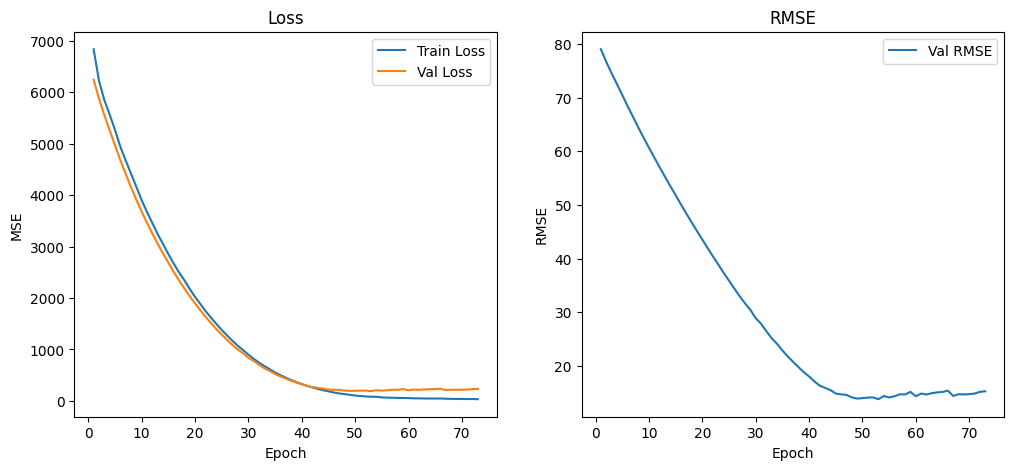

In [43]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss")

# RMSE
plt.subplot(1,2,2)
plt.plot(epochs, val_rmse_hist, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE")

plt.show()

## 4.3 Testing

In [44]:
test_loss, test_rmse, test_phm = evaluate_lstm(
    best_lstm_model,
    test_loader,
    loss_fun,
    Device
)

print(f"Test MSE:  {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test PHM:  {test_phm:.2f}")

Test MSE:  298.1566
Test RMSE: 17.2672
Test PHM:  617.10


In [45]:
lstm_results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_rmse": val_rmse_hist,
    "val_phm": val_phm_hist,
    "train_time_sec": lstm_train_time,
    "best_epoch": checkpoint["epoch"],
    "best_val_rmse": checkpoint["val_rmse"],
    "best_val_phm": checkpoint["val_phm"],
    "test_mse": test_loss,
    "test_rmse": test_rmse,
    "test_phm": test_phm,
}

torch.save(lstm_results, "lstm_training_history.pt")

# 5 Model variant: TCN

## 5.1 Model definition

We implement a Temporal Convolutional Network (TCN) following Bai et al., integrating causal convolutions, residual blocks, weight normalization, dropout regularization, and exponentially increasing dilation to effectively capture long-range temporal dependencies.

In [46]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = weight_norm(nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=0,
            dilation=dilation
        ))

    def forward(self, x):
        x = F.pad(x, (self.pad, 0))   # left padding only
        return self.conv(x)


class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()

        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

        self.final_relu = nn.ReLU()

    def forward(self, x):
        residual = self.downsample(x) # shape: (batch, 32, 50)

        out = self.conv1(x)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.relu2(out)
        out = self.drop2(out) # shape: (batch, 32, 50)

        return self.final_relu(out + residual)


class TCN_model(nn.Module):
    def __init__(self, in_channels=17, channels=[32,32,32,32], kernel_size=3, dropout=0.2):
        super().__init__()

        blocks = []
        current_channels = in_channels

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            blocks.append(TCNBlock(current_channels, out_channels, kernel_size, dilation, dropout))
            current_channels = out_channels

        self.tcn = nn.Sequential(*blocks)
        self.fc = nn.Linear(channels[-1], 1)

    def forward(self, x):
        # x: (batch, 50, 17)
        x = x.permute(0, 2, 1)   # (batch, 17, 50)
        x = self.tcn(x)          # (batch, 32, 50)
        x = x[:, :, -1]          # (batch, 32)
        x = self.fc(x)           # (batch, 1)
        return x

In [47]:
variant_model = TCN_model()
print(variant_model)

TCN_model(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(17, 32, kernel_size=(3,), stride=(1,))
      )
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,))
      )
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(17, 32, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), dilation=(2,))
      )
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), dilation=(2,))
      )
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (downsample): Identity()
      (final_relu): ReLU()
    )
    (2): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(32

C:\Users\diego\anaconda3\envs\mlpytorch\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [48]:
variant_model = variant_model.to(Device)

## 5.2 Training and validation

To ensure a fair comparison with the LSTM baseline, we reuse the same training pipeline, including loss function, optimizer configuration, evaluation metrics, and early stopping criteria. This isolates the effect of the model architecture, allowing performance differences to be attributed solely to the use of the TCN.

In [49]:
checkpoint_path = "tcn_best.pt"

In [50]:
optimizer = torch.optim.Adam(
    variant_model.parameters(),
    lr=lr,
    weight_decay=1e-5
)

train_losses, val_losses = [], []
val_rmse_hist, val_phm_hist = [], []
best_val_rmse = float("inf")
best_epoch = -1
bad_epochs = 0
checkpoint_path = "tcn_best.pt"

In [51]:
from tqdm.auto import tqdm
start_time = time.time()

for epoch in tqdm(range(N_epochs), desc="Training TCN"):

    variant_model.train()
    batch_losses = []

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        X = X.to(Device, non_blocking=True).float()
        y = y.to(Device, non_blocking=True).float().view(-1, 1)

        optimizer.zero_grad()
        y_pred = variant_model(X)
        if epoch == 0 and len(batch_losses) == 0:
            print(f"Forward output device: {y_pred.device}")
        loss = loss_fun(y_pred, y)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    val_loss, val_rmse, val_phm = evaluate_lstm(
        variant_model, val_loader, loss_fun, Device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmse_hist.append(val_rmse)
    val_phm_hist.append(val_phm)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(
        f"Epoch {epoch+1:03d} | "
        f"train_MSE={train_loss:.4f} | "
        f"val_MSE={val_loss:.4f} | "
        f"val_RMSE={val_rmse:.4f} | "
        f"val_PHM={val_phm:.2f}"
        )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        bad_epochs = 0

        best_state = copy.deepcopy(variant_model.state_dict())

        torch.save({
            "epoch": best_epoch,
            "model_state_dict": best_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "val_rmse": val_rmse,
            "val_phm": val_phm,
            "val_loss": val_loss,
            "history": {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_rmse": val_rmse_hist,
                "val_phm": val_phm_hist,
            }
        }, checkpoint_path)

    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping.")
        break

Training TCN:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/396 [00:00<?, ?it/s]

Forward output device: cuda:0
Epoch 001 | train_MSE=3102.8486 | val_MSE=605.9175 | val_RMSE=24.6154 | val_PHM=38765.57


Epoch 2:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/396 [00:00<?, ?it/s]

...

Epoch 35:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 36:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 37:   0%|          | 0/396 [00:00<?, ?it/s]

Epoch 38:   0%|          | 0/396 [00:00<?, ?it/s]

Early stopping.


In [52]:
tcn_train_time = time.time() - start_time
print(f"TCN training time: {tcn_train_time/60:.2f} min")

TCN training time: 32.40 min


In [53]:
# Restore best model
best_tcn_model = variant_model
checkpoint = torch.load(checkpoint_path, map_location=Device)
best_tcn_model.load_state_dict(checkpoint["model_state_dict"])

print(
    f"Best TCN checkpoint | "
    f"epoch={checkpoint['epoch']} | "
    f"val_RMSE={checkpoint['val_rmse']:.4f} | "
    f"val_PHM={checkpoint['val_phm']:.2f}"
)

Best TCN checkpoint | epoch=18 | val_RMSE=16.1943 | val_PHM=12247.46


C:\Users\diego\AppData\Local\Temp\ipykernel_17884\600541389.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=Device)

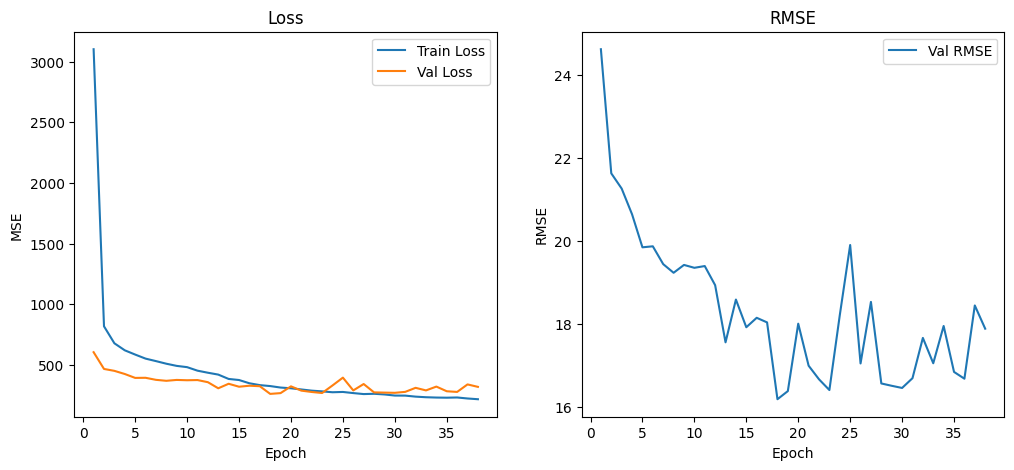

In [54]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss")

# RMSE
plt.subplot(1,2,2)
plt.plot(epochs, val_rmse_hist, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE")

plt.show()

## 5.3 Testing

In [55]:
test_loss, test_rmse, test_phm = evaluate_lstm(
    best_tcn_model,
    test_loader,
    loss_fun,
    Device
)

print(f"Test MSE:  {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test PHM:  {test_phm:.2f}")

Test MSE:  246.5067
Test RMSE: 15.7005
Test PHM:  427.06


In [56]:
tcn_results = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_rmse": val_rmse_hist,
    "val_phm": val_phm_hist,
    "train_time_sec": tcn_train_time,
    "best_epoch": checkpoint["epoch"],
    "best_val_rmse": checkpoint["val_rmse"],
    "best_val_phm": checkpoint["val_phm"],
    "test_mse": test_loss,
    "test_rmse": test_rmse,
    "test_phm": test_phm,
}

torch.save(tcn_results, "tcn_training_history.pt")